# ColPali with OpenSearch




In [ ]:
!pip install setuptools==58.2.0
!pip install -q transformers>=4.45.0
!pip install colpali_engine>=0.3.1
!pip install datasets
!pip install opensearch-py
!pip install requests_aws4auth
!pip install ranx
!pip install -q -U "colpali-engine[interpretability]>=0.3.2,<0.4.0"

In [1]:
from colpali_engine.models import ColPali, ColPaliProcessor
from datasets import load_dataset
import torch
from tqdm import tqdm
import json
import random
from ranx import compare, Qrels, Run
import pprint
from io import BytesIO
from pathlib import Path
from typing import Optional, cast

import matplotlib.pyplot as plt
import requests
import torch
from colpali_engine.interpretability import (
    get_similarity_maps_from_embeddings,
    plot_all_similarity_maps,
    plot_similarity_map,
)
from colpali_engine.models import ColPali, ColPaliProcessor
from colpali_engine.utils.torch_utils import get_torch_device
from PIL import Image

In [2]:
model_name = (
    "vidore/colpali-v1.3"
)
colpali_model = ColPali.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="cuda:0",  # Use "cuda:0" for GPU, "cpu" for CPU, or "mps" for Apple Silicon
).eval()

colpali_processor = ColPaliProcessor.from_pretrained(
    model_name
)

`config.hidden_act` is ignored, you should use `config.hidden_activation` instead.
Gemma's activation function will be set to `gelu_pytorch_tanh`. Please, use
`config.hidden_activation` if you want to override this behaviour.
See https://github.com/huggingface/transformers/pull/29402 for more details.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [14]:
dataset_vs = load_dataset("vespa-engine/gpfg-QA", split="train")
len(dataset_vs)

6992

In [42]:
from tqdm import tqdm
from datasets import load_dataset
import json
import boto3
from opensearchpy import OpenSearch, RequestsHttpConnection, AWSV4SignerAuth
from requests.auth import HTTPBasicAuth
from requests_aws4auth import AWS4Auth
batch_size = 10 #based on GPU's
image_seq_length = 1024 #the parameter of ColPali https://huggingface.co/vidore/colpali-v1.3/blob/main/preprocessor_config.json
# max_pool = []
# mean_pool = []

OpenSearchDomainEndpoint = 'search-opensearchservi-shjckef2t7wo-iyv6rajdgxg6jas25aupuxev6i.us-west-2.es.amazonaws.com'
service = 'es'
credentials = boto3.Session().get_credentials()
#awsauth = AWS4Auth(credentials.access_key, credentials.secret_key, 'us-west-2', service, session_token=credentials.token)
awsauth = HTTPBasicAuth("master","ML-Search123!")
headers = { "Content-Type": "application/json"}
batch = 0
count = 0
body_ = ''
batch_size = 10
aos_client = OpenSearch(
    hosts = [{'host': OpenSearchDomainEndpoint, 'port': 443}],
    http_auth = awsauth,
    use_ssl = True,
    connection_class = RequestsHttpConnection
)

In [ ]:
query = {
   "size": 100,
   "_source": {
        "exclude": [ "page_sub_vectors","text" ]
    },
   "query": {
      "function_score": {
         "functions": [
            {
               "random_score": {
                  "seed": "1477072619038"
               }
            }
         ]
      }
   }
}

response = aos_client.search(
        body = query,
        index = 'colpali-vs'
    )
response['hits']['hits']

In [57]:
vs_queries = dataset_vs['queries']
vs_questions = dataset_vs['questions']
question_ = random.sample(vs_queries, 100)#['financial statements norwegian pension fund']
q_ = []
for q in question_:
    if(len(q)!=0):
        q_.append(q[0])
        q__.append()
print(q_)
question = q_[:100]    

['palm oil production risk management', 'norwegian government pension fund global report', 'norwegian government pension fund global return', 'norwegian government pension fund income statement', 'norwegian government pension fund global investments', 'hedge fund strategies', 'investment performance analysis', 'norwegian pension fund income expense', 'real estate decarbonization', 'norges bank management costs', 'norwegian pension fund holdings', 'real estate investment changes', 'norwegian government pension fund global', 'norwegian government pension fund global market volatility', 'financial reporting government pension fund global', 'norges bank investment management performance', 'equity management european turmoil', 'government pension fund global income expense', 'financial crisis correlation', 'norwegian pension fund global 2009', 'norges bank investment management', 'norwegian pension fund recruitment', 'government pension fund global fixed income', 'global economic growth 201

['palm oil production risk management',
 'norwegian government pension fund global report',
 'norwegian government pension fund global return',
 'norwegian government pension fund income statement',
 'norwegian government pension fund global investments',
 'hedge fund strategies',
 'investment performance analysis',
 'norwegian pension fund income expense',
 'real estate decarbonization',
 'norges bank management costs',
 'norwegian pension fund holdings',
 'real estate investment changes',
 'norwegian government pension fund global',
 'norwegian government pension fund global market volatility',
 'financial reporting government pension fund global',
 'norges bank investment management performance',
 'equity management european turmoil',
 'government pension fund global income expense',
 'financial crisis correlation',
 'norwegian pension fund global 2009',
 'norges bank investment management',
 'norwegian pension fund recruitment',
 'government pension fund global fixed income',
 'glo

In [75]:
question = [question[0]]
question

['palm oil production risk management']

In [43]:
question = ["what is the proportion of female new hires 2021-2023?"]#palm oil production risk management

In [17]:
question = ["climate change responsible investment","norwegian government pension fund global annual report","responsible investment 2016","norges bank investment real estate","risk exposure investment","government pension fund global performance","responsible investment policy","norges bank financial report","norges bank investment management annual report","norges bank investment management","norwegian pension fund global stock market performance","global financial markets 2007","counterparty risk norwegian pension fund","norges bank counterparty risk","nbim management costs","external fixed income managers","norwegian government pension fund global report 2023","equity holdings europe 1998","government pension fund global","water management climate change risk","responsible investment policy norwegian pension fund","norwegian government pension fund global investments frontier markets","norges bank operational risk","government petroleum fund returns","norwegian pension fund global investment","norwegian pension fund global returns","norges bank conference","norwegian pension fund investment","government pension fund global strategy","fixed income management 2011","norges bank investment management gips","norges bank management fees","norges bank investment fund","responsible investment nbim","equity investment risk measures","equity holdings global fund","norges bank responsible investment","norwegian pension fund returns 2010","fund currency basket returns","risk adjusted measures equity fixed income","norwegian pension fund income expense","operational risk management nbim","fee schedule performance","fixed income investments 2014","norwegian government pension fund global asset mix","norges bank petroleum fund return 2004","equity benchmark FTSE GEISAC","norwegian government pension fund bond portfolio","norwegian petroleum fund portfolio","norwegian pension fund management costs","global market trends third quarter","norges bank investment benchmark","global equity markets 2007","norges bank investment management performance","norwegian pension fund global investments","norwegian government pension fund","composite gross return","norwegian pension fund global report","fixed income investments returns","norges bank investment risk","norwegian pension fund returns 2007","norges bank investment management proxy access","government pension fund global fixed income","norges bank investment performance","norges bank investment performance","unlisted real estate returns risk","norwegian government pension fund counterparty risk","norwegian government pension fund global return","global pension fund 2008 equity allocation","financial derivatives GPFG","norges bank petroleum fund risk","gpf global equity bonds derivatives","government pension fund global report","norges bank investment portfolio allocation","renewable energy investments","sustainability shareholder voting","water risk management companies","real estate investment risk management","norges bank management costs","norges bank investment strategy","norwegian pension fund returns","investment portfolio performance","norges bank interim financial report","fixed income investments","norges bank investment management benchmark","norges bank counterparty risk","norges bank management costs","norges bank equity benchmark","government pension fund global performance","norwegian government pension fund global bonds","norwegian government pension fund global exercising ownership","norwegian government pension fund global report","norwegian pension fund investments","unlisted renewable energy infrastructure valuation","norges bank investment management risk","norwegian government pension fund global factor exposures","norwegian pension fund bond holdings"]

In [76]:
with torch.no_grad():
    batch_query = colpali_processor.process_queries([question[0]]).to(
        colpali_model.device
    )
    print(colpali_processor.tokenizer.tokenize(
        colpali_processor.decode(batch_query.input_ids[0])
    ))

['<bos>', 'Query', ':', '▁palm', '▁oil', '▁production', '▁risk', '▁management', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '\n']


In [77]:
def colpali_query(query): #per query
    with torch.no_grad():
        batch_query = colpali_processor.process_queries([query]).to(
            colpali_model.device
        )
        mask_without_pad = batch_query.input_ids.bool().unsqueeze(-1)
    query_embedding = colpali_model(**batch_query)
    query_without_pad = torch.masked_select(query_embedding, mask_without_pad).view(1, -1, 128)
    return {
        "full": query_embedding[0].cpu().float().numpy().tolist(),
        "cut": query_without_pad[0].cpu().float().numpy().tolist()
    }

In [78]:
ufo_queries_sample_embeddings = [colpali_query(sample) for sample in question]


In [79]:
len(ufo_queries_sample_embeddings[0]['full'])

19

In [80]:
batch_size = 8
final_docs_sorted_20 = []
for i in ufo_queries_sample_embeddings:
    batch_embeddings = i['full']
    a = np.array(batch_embeddings)
    vec = a.mean(axis=0)
    #print(i)
    hits = []
    #for v in batch_embeddings:
    query = {
        "size": 200,
          "query": {
            "nested": {
              "path": "page_sub_vectors",
              "query": {
                "knn": {
                  "page_sub_vectors.page_sub_vector": {
                    "vector": vec.tolist(),
                    "k": 200
                  }
                }
              }
                }
              }
            }
    response = aos_client.search(
        body = query,
        index = 'colpali-vs'
    )
    #print(response)
    token_vectors = batch_embeddings
    final_docs = []
    hits += response['hits']['hits']
    #print(len(hits))
    for ind,j in enumerate(hits):
        max_score_dict_list = []
        doc={"id":j["_id"],"score":j["_score"],"image":j["_source"]["image"]}
        with_s = j['_source']['page_sub_vectors']
        add_score = 0

        for index,i in enumerate(token_vectors):
            query_token_vector = np.array(i)
            scores = []
            for m in with_s:
                doc_token_vector = np.array(m['page_sub_vector'])
                score = np.dot(query_token_vector,doc_token_vector)
                scores.append(score)
                
            scores.sort(reverse=True)
            max_score = scores[0]
            add_score+=max_score
            
        doc["total_score"] = add_score
        final_docs.append(doc)
    final_docs_sorted = sorted(final_docs, key=lambda d: d['total_score'], reverse=True)
    final_docs_sorted_20.append(final_docs_sorted[:30])
   
    
final_docs_sorted_20


[[{'id': '_cSCb5YBkiQuoz1Q8ZaD',
   'score': 0.7607734,
   'image': 'vs/vs_3805.JPEG',
   'total_score': 9.372801658697426},
  {'id': 'zfSKb5YBcuw9xT4llK4-',
   'score': 0.7621297,
   'image': 'vs/vs_4376.JPEG',
   'total_score': 7.846790423925995},
  {'id': 'nMRqb5YBkiQuoz1Qe5R1',
   'score': 0.73568356,
   'image': 'vs/vs_1977.JPEG',
   'total_score': 7.825635458904799},
  {'id': 'O_R6b5YBcuw9xT4lhK2r',
   'score': 0.71277654,
   'image': 'vs/vs_3178.JPEG',
   'total_score': 7.766373954025312},
  {'id': 'HUtyb5YBTp0efWqBxRwF',
   'score': 0.743482,
   'image': 'vs/vs_2595.JPEG',
   'total_score': 7.469022656288871},
  {'id': 'v0tkb5YBTp0efWqBVBpB',
   'score': 0.74273115,
   'image': 'vs/vs_1532.JPEG',
   'total_score': 7.304789238125522},
  {'id': 'q_Rqb5YBcuw9xT4le6vK',
   'score': 0.71146864,
   'image': 'vs/vs_1978.JPEG',
   'total_score': 7.249549822550762},
  {'id': 'evRyb5YBcuw9xT4lxaxV',
   'score': 0.7159844,
   'image': 'vs/vs_2596.JPEG',
   'total_score': 6.590556472943717

In [81]:
answers = []

for i in question:
    print(i)
    response = aos_client.search(
        body = {"query":{"match":{"queries":i}},"size":1},#specific_detail_query
        index = 'colpali-vs'
    )
    #print(response)
    answers.append(response['hits']['hits'][0]['_source']['image'])
eval_ = []
for id_1,j in enumerate(answers):
    exists = False
    for id_2,k in enumerate(final_docs_sorted_20[id_1]):
        if(j == k['image']):
            exists = True
            eval_.append({"exists":exists,"position":id_2})
            
            break
    if(exists == False):
        eval_.append({"exists":exists,"position":-1})

(eval_)

palm oil production risk management


[{'exists': True, 'position': 0}]

In [82]:
instance_to_test = 0
top_pdf_ann_rerank = final_docs_sorted_20[0][instance_to_test]['image']
top_pdf_ann_rerank

'vs/vs_3805.JPEG'

## Similarity Map

In [83]:
def load_image_from_url(url: str) -> Image.Image:
    """
    Load a PIL image from a valid URL.
    """
    #response = requests.get(url)
    return Image.open(url)


def scale_image(image: Image.Image, new_height: int = 1024) -> Image.Image:
    """
    Scale an image to a new height while maintaining the aspect ratio.
    """
    # Calculate the scaling factor
    width, height = image.size
    aspect_ratio = width / height
    new_width = int(new_height * aspect_ratio)

    # Resize the image
    scaled_image = image.resize((new_width, new_height))

    return scaled_image

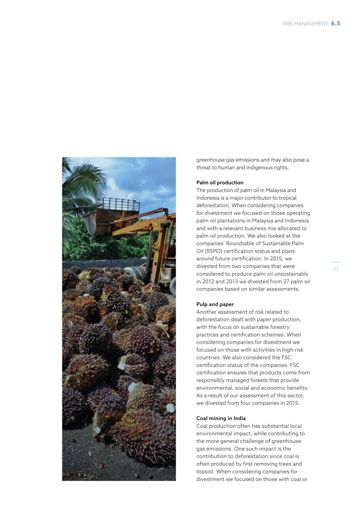

In [84]:
# ==========================     USER INPUTS     ==========================

image_filepath: Optional[str] = None  # "shift_kazakhstan.jpg"
query: str = question[0]

# =========================================================================

if image_filepath:
    assert Path(image_filepath).is_file(), f"Cannot find the image file at `{image_filepath}`"
    image = Image.open(image_filepath)
else:
    image = load_image_from_url(top_pdf_ann_rerank)
# Preview the image
scale_image(image, 512)

In [85]:
# Preprocess inputs
batch_images = colpali_processor.process_images([image]).to(colpali_model.device)

#colpali_processor.process_images([dataset[0]["image"]]).to(colpali_model.device)
batch_queries = colpali_processor.process_queries([question[0]]).to(colpali_model.device)

# Forward passes
with torch.no_grad():
    image_embeddings = colpali_model.forward(**batch_images)
    query_embeddings = colpali_model.forward(**batch_queries)

In [86]:
# Get the number of image patches
n_patches = colpali_processor.get_n_patches(image_size=image.size, patch_size=colpali_model.patch_size)

print(f"Number of image patches: {n_patches}")

# Get the tensor mask to filter out the embeddings that are not related to the image
image_mask = colpali_processor.get_image_mask(batch_images)

Number of image patches: (32, 32)


In [87]:
# Generate the similarity maps
batched_similarity_maps = get_similarity_maps_from_embeddings(
    image_embeddings=image_embeddings,
    query_embeddings=query_embeddings,
    n_patches=n_patches,
    image_mask=image_mask,
)

# Get the similarity map for our (only) input image
similarity_maps = batched_similarity_maps[0]  # (query_length, n_patches_x, n_patches_y)

print(f"Similarity map shape: (query_length, n_patches_x, n_patches_y) = {tuple(similarity_maps.shape)}")

Similarity map shape: (query_length, n_patches_x, n_patches_y) = (19, 32, 32)


In [88]:
# Use this cell output to choose a token using its index
query_content = colpali_processor.decode(batch_queries.input_ids[0]).replace(colpali_processor.tokenizer.pad_token, "")
query_content = query_content.replace(colpali_processor.query_augmentation_token, "").strip()
query_tokens = colpali_processor.tokenizer.tokenize(query_content)

pprint.pprint({idx: val for idx, val in enumerate(query_tokens)})

{0: '<bos>',
 1: 'Query',
 2: ':',
 3: '▁palm',
 4: '▁oil',
 5: '▁production',
 6: '▁risk',
 7: '▁management'}


In [89]:
# Choose a token using its index
token_idx = 3

print(f"Selected token: `{query_tokens[token_idx]}`")

# Retrieve the similarity map for the chosen token
current_similarity_map = similarity_maps[token_idx]  # (n_patches_x, n_patches_y)

Selected token: `▁palm`


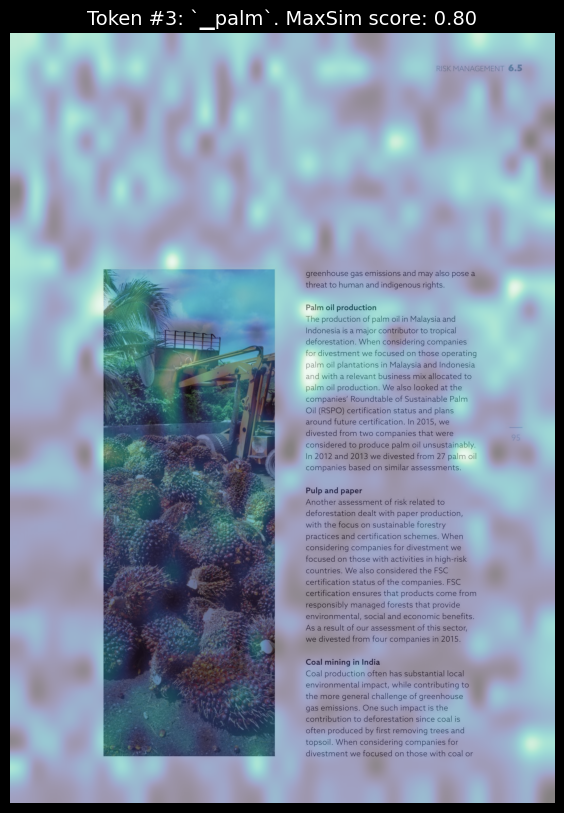

In [90]:
fig, ax = plot_similarity_map(
    image=image,
    similarity_map=current_similarity_map,
    figsize=(8, 8),
    show_colorbar=False,
)

max_sim_score = similarity_maps[token_idx, :, :].max().item()
ax.set_title(f"Token #{token_idx}: `{query_tokens[token_idx]}`. MaxSim score: {max_sim_score:.2f}", fontsize=14)

fig

In [91]:
plots = plot_all_similarity_maps(
    image=image,
    query_tokens=query_tokens,
    similarity_maps=similarity_maps,
    figsize=(8, 8),
    show_colorbar=False,
    add_title=True,
)

for idx, (fig, ax) in enumerate(plots):
    savepath = f"similarity_map_{idx}.png"
    fig.savefig(savepath, bbox_inches="tight")
    print(f"Similarity map for token `{query_tokens[idx]}` saved at `{savepath}`")

plt.close("all")

Similarity map for token `<bos>` saved at `similarity_map_0.png`
Similarity map for token `Query` saved at `similarity_map_1.png`
Similarity map for token `:` saved at `similarity_map_2.png`
Similarity map for token `▁palm` saved at `similarity_map_3.png`
Similarity map for token `▁oil` saved at `similarity_map_4.png`
Similarity map for token `▁production` saved at `similarity_map_5.png`
Similarity map for token `▁risk` saved at `similarity_map_6.png`
Similarity map for token `▁management` saved at `similarity_map_7.png`


In [92]:
import boto3
from IPython.display import display, Markdown
import base64

client = boto3.client("bedrock-runtime")

def call_nova(
    model,
    messages,
    system_message="",
    streaming=False,
    max_tokens=512,
    temp=0.0001,
    top_p=0.99,
    top_k=20,
    tools=None,
    verbose=False,
):
    client = boto3.client("bedrock-runtime")
    system_list = [{"text": system_message}]
    inf_params = {
        "max_new_tokens": max_tokens,
        "top_p": top_p,
        "top_k": top_k,
        "temperature": temp,
    }
    request_body = {
        "messages": messages,
        "system": system_list,
        "inferenceConfig": inf_params,
    }
    if tools is not None:
        tool_config = []
        for tool in tools:
            tool_config.append({"toolSpec": tool})
        request_body["toolConfig"] = {"tools": tool_config}
    if verbose:
        print("Request Body", request_body)
    if not streaming:
        response = client.invoke_model(modelId=model, body=json.dumps(request_body))
        model_response = json.loads(response["body"].read())
        return model_response, model_response["output"]["message"]["content"][0]["text"]
    else:
        response = client.invoke_model_with_response_stream(
            modelId=model, body=json.dumps(request_body)
        )
        return response["body"]
def get_base64_encoded_value(media_path):
    with open(media_path, "rb") as media_file:
        binary_data = media_file.read()
        base_64_encoded_data = base64.b64encode(binary_data)
        base64_string = base_64_encoded_data.decode("utf-8")
        return base64_string
    

def print_output(content_text):
    display(Markdown(content_text))

In [93]:
system_message = "given an image of a PDF page, answer the question. Be accurate to the question. If you don't find the answer in the page, please say, I don't know"
messages = [
    {
        "role": "user",
        "content": [
            {
                "image": {
                    "format": "jpeg",
                    "source": {
                        "bytes": get_base64_encoded_value(
                            top_pdf_ann_rerank
                        )
                    },
                }
            },
            {
                "text": question[0]#"What were the credit ratings of Norges Bank's counterparties (excluding brokers) at the end of 2021?"
            },
        ],
    }
]
model_response, content_text = call_nova(
    "amazon.nova-pro-v1:0", messages, system_message=system_message, max_tokens=300
)

print("\n[Response Content Text]")
print_output(content_text)


[Response Content Text]


The production of palm oil in Malaysia and Indonesia is a major contributor to tropical deforestation. When considering companies for divestment we focused on those operating palm oil plantations in Malaysia and Indonesia and with a relevant business mix allocated to palm oil production. We also looked at the companies' Roundtable of Sustainable Palm Oil (RSPO) certification status and plans around future certification. In 2015, we divested from two companies that were considered to produce palm oil unsustainably. In 2012 and 2013 we divested from 27 palm oil companies based on similar assessments.